In [1]:
from tara_preprocessing import get_just_ecog_data,get_electrode_normalized_loc,car
from noah_production_funcs import single_patient_prediction_pure,create_lapaican_rbf,create_lapaican_knn
from tara_preprocessing import remove_duplicates, hold_out, preprocessing,apply_car_function,clip_time_series
from tara_preprocessing import make_patient_correlation_matrix
from noah_production_funcs import create_u
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import geoopt
import tqdm

## Notes for futre me:

Here is the list of clipped patient dimensions:
(256000, 46)
(256000, 41)
(256000, 50)
(256000, 31)
(256000, 52)
(251240, 39)
(256000, 60)
(256000, 56)
(256000, 102)
(256000, 58)
(256000, 42)
(180920, 40)
(256000, 39)
(256000, 58)

for some reason, some are shorter in the time dimension 

In [2]:
data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)
print('Downloaded data')
#ecogs = clip_time_series(ecogs)
#print("Time series clipped")
ecogs_no_dups,xyz_no_dups = remove_duplicates(ecogs,xyz)
print('Removed duplicate electrodes')
xyz_clea, cleane = preprocessing(ecogs_no_dups,xyz_no_dups,notch_size=.05)
print("Done Preprocessing")
#cleaned_f,xyz_f,fake_pat_beginning = hold_out(xyz_clea,cleane,0,[40,41])
#cleaned_f = apply_car_function(cleaned_f,0)
#print("Done holding out electrodes")


[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

# Data_loader testing

In [22]:
from sklearn.neighbors import NearestNeighbors

In [23]:
num_nodes = xyz_clea.shape[0] 
neighbors = NearestNeighbors(n_neighbors=10).fit(xyz_clea)
distanceofneighbors,indicesofneighbors = neighbors.kneighbors(return_distance=True)

array([148, 106, 158,  12,   0,  11, 105,   2, 375, 111])

In [24]:
distanceofneighbors

array([[ 3.29598973,  4.24875804,  5.25554722, ..., 11.77753665,
        12.21020351, 12.71836288],
       [ 5.48256646,  7.53212821,  7.66242593, ..., 10.27072666,
        11.54958332, 12.11447994],
       [ 4.51807864,  6.19622286,  8.96421416, ..., 12.08171321,
        12.19974289, 13.41186414],
       ...,
       [ 7.90777835, 10.33399856, 14.91258783, ..., 20.42195715,
        20.84358372, 22.29812037],
       [ 7.90777835,  9.14612446, 10.09222879, ..., 18.44125138,
        22.01291282, 22.3343792 ],
       [ 9.14612446,  9.20444106, 15.70409053, ..., 24.19453434,
        24.36228744, 24.70682344]], shape=(541, 10))

In [ ]:
from sklearn.neighbors import NearestNeighbors

class DataLoader:
    #! CRITICAL: xyz IS JUST THE PATIENTS ELECTRODES, NOT EVERYONES, THIS IS VERY IMPORTANT TO REMEMBER
    def __init__(self,limit,patient,window_size,ecogs,desired_node_iters,elecs_to_hold,xyz,k):
        self.limit = limit #max number of data points we will allow to be generated
        self.current_total_iter = 0
        self.current_node_iter = 0 #this is the indicated of how many many of this patients electrodes FOR THIS SPECFIC ELECTRODE WE HOLD OUT, have we gone thorugh
        self.patient = patient
        self.window_size = window_size
        self.desired_node_iters = desired_node_iters #desired number of datapoints we want to make per node (ie number of window slices to make)
        
        self.ecog = ecogs[patient]
        self.elecs_to_hold = elecs_to_hold #this is a list of the electrodes to hold out at some point 
        self.xyz = xyz #node locations
        self.k = k #the number of neighbors to connect together

        self.num_nodes = self.ecog.shape[1]
        self.node_held = elecs_to_hold[0] #the first electrode we are holds
        self.node_held_index = 0 
        if self.ecog.shape[0] < window_size * desired_node_iters: #makes sure we have enough data to calcuate this
            raise ValueError(f"The number of data points you want to generate:{desired_node_iters} with a window size of:{window_size} is more then we have the data to do, ecog has timelength: {self.ecog.shape[0]}")
        ####### make the patient graph useing knn #######
        num_nodes = xyz.shape[0] 
        neighbors = NearestNeighbors(n_neighbors=k).fit(xyz)
        distanceofneighbors,indicesofneighbors = neighbors.kneighbors(return_distance=True) #gets the indices of the 10 (or k) neighbors of each node

        # turn indices lists into pairwiase combos
        all_edges = []
        all_edges_weights = []
        iter = 0 #iter is the node of which we are considering its neightbors
        for indexs,distances in zip(indicesofneighbors,distanceofneighbors):
            for num,dist in zip(indexs,distances): #the neighbors of node 'iter'
                all_edges.append([iter,num])
                all_edges.append([num,iter]) #adds the edge going the other direction 
                all_edges_weights.append(dist)#adds the distance twice, because technically two edges exist
                all_edges_weights.append(dist)
            iter += 1
        self.graph_edges = np.array(all_edges)
        self.graph_weights = np.array(all_edges_weights) 



    def __iter__(self):
        return self
    

    def __next__(self):
        #checks, have we gone over the max datapoints we want to generate
        if self.current_total_iter >= self.limit: 
            raise StopIteration
        #ie we have generated enought points for this electrode so we that we will move on to the next
        # or have we done wnough window blocks for our purposes
        if self.desired_node_iters <= self.current_node_iter: 
            #checks, if this was the last of the nodes we want to hold out, if so, end
            if self.node_held_index == len(self.elecs_to_hold)-1: 
                raise StopIteration
            #otherwise
            self.current_node_iter = 0 #reset number of datapoints we have made
            self.node_held_index +=1 #change what electrode we are dealing with (in local list of elecs_to_hold)
            self.node_held = self.elecs_to_hold[self.node_held_index] #what node we are dealing with in larger list
        
        #get the node features
        # remember: self.current_node_iter determines where in the timeseries we are when times with the window sie
        node_features = []
        node_held = None
        for i in range(self.num_nodes): #for each node
            if i !=self.node_held:  #if its one we dont hold out
                window_start = self.current_node_iter * self.window_size #make window frame
                window_end = window_start + self.window_size
                ecog_masked = self.ecog[window_start:window_end,i] #for this node, we get this window
                node_features.append(ecog_masked)
            #if we are dealing with the held out node, replace it with all zeros
            elif i == self.node_held: 
                node_features.append(np.zeros(self.window_size))

                window_start = self.current_node_iter * self.window_size #make window frame
                window_end = window_start + self.window_size
                node_held = self.ecog[window_start:window_end,i]
                

        node_features = np.array(node_features)
        self.current_total_iter +=1
        self.current_node_iter +=1
        #[node_features,self.graph_edges,self.graph_weights,node_held]
        return {"features":node_features,"edges":self.graph_edges,"weights":self.graph_weights,"target":node_held}

        


In [61]:
def get_1_patient_locations(pat,ecogs,xyz):
    elec_nums = []
    for temp in ecogs: #gets the number of electrodes for each patient
        elec_nums.append(temp.shape[1])

    pat_index_start = 0
    pat_index_end = 0
    for i,num in enumerate(elec_nums): #makes the starting and ending indices forthis patient
        if i < pat: #adds up all the patients before this one to get the starting node (inclusive)
            pat_index_start += num
        if i <= pat:#adds up all the patients before this one AND ITSELF to get the ending node (exclusive)
            pat_index_end += num
    return xyz[pat_index_start:pat_index_end]

In [ ]:
cleane[0].shape[0]

(271400, 42)

In [63]:
temp_loc = get_1_patient_locations(0,cleane,xyz_clea)

In [ ]:
loader = DataLoader(limit=10000000,patient=0,window_size=800,ecogs=cleane,desired_node_iters=10,elecs_to_hold=[0,1,2,3,4,5,6,7],xyz=temp_loc,k=10)

In [76]:
win_size = 800
x = 0
for pat_index in range(len(cleane)): #for each patient
    pat_locs = get_1_patient_locations(pat_index,cleane,xyz_clea)
    desired_iter_per_node = cleane[pat_index].shape[0]/win_size - 200 #timeseries length over window size with a little bit of wiggle room for safety
    pat_num_nodes = cleane[pat_index].shape[1]
    print(np.random.randint(low=0,high=pat_num_nodes-1,size=int(pat_num_nodes/2)))
    loader = DataLoader(limit=10000000,patient=pat_index,window_size=800,ecogs=cleane,desired_node_iters=desired_iter_per_node,elecs_to_hold=[0,1,2,3,4,5,6,7],xyz=pat_locs,k=10)
    for i in loader:
        #print(i['edges'].shape)
        x += 1

[27 17 26 32 32 10 33 24 38 25  6 26  1 19 30 38 37 21 23  0 14]
[11 32 38  3 24  3 10 27 37  5 12  7 28 30  2 38  0 25 31 22]
[45 40 34 26 40 29  7  1 33  9  5 20 39 40  3 12  5 33 43 21 22 28  0  2]
[ 8 19  8 17 21 19  2 20 24 15 21 18 24 17 12]
[1 3 4 6 9]
[10  0 16 34  1 26 33  8 14 36 10  9 23 28 21 21 14 25  3]
[ 5 10 21  5  3  6 13 34  8  0 24 24  1 20  8 26  7 33]
[67 56  3 15 81  4 72 58 81 28  1 29 32 58 19 47 39 38  0 13  8 45 94 22
 12 94 45  9 48  7 75 15 56 37 37  9 80 46 59 69 92 18 76 63 32  4 20 56]
[16  7  7  4  5  7  7  7 17]
[20 24  6  4 14 31 13 23 36  7  5 28 39 37 14  7 36  1 24 24]
[16 15 31 38 22 36  9 34 17 28 25  7 11 11  5  8 26 27 16 17]
[ 9 24 24 34  0 30 34 18 34 13 14  9 14 11 28 20  1 19  2]
[50 43 52 47 17 46  3 36 51 45 56 53 42 53  9 11 46 37 37 26 36  8 46  7
  3 20  6 19 36]


In [65]:
for i in loader:
    print("++++++++++++++++")
    print(i['edges'].shape)

++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)
++++++++++++++++
(840, 2)


In [20]:
class DataLoad:
    def __init__(self,limit):
        self.limit = limit
        self.current = 0
    def __iter__(self):
        return self
    def __next__(self):
        if self.current < self.limit:
            val= self.current
            self.current +=1
            return val
        else:
            raise StopIteration


In [21]:


for i in DataLoad(6):
    print(i)

0
1
2
3
4
5


In [115]:
patient_corr_mat = make_patient_correlation_matrix(xyz_f,cleaned_f)
print('Got Correlation Matrices, done!')
#U_det, loss = create_u(k=40,r=500,lamb=0.001,patient_corr_mat=patient_corr_mat,xyz_clean=xyz_f,training_steps=800,graph='rbf') #.0005

Got Correlation Matrices, done!


In [87]:
def project_diag(K):
    K.fill_diagonal_(1)
    #np.fill_diagonal(K, 1) #works in place
    return K

def project_psd(K):
    K_temp = (K + K.T) / 2
    eigenvalues,eigenvectors = np.linalg.eigh(K_temp)
    D = torch.zeros(K.shape)
    new_eigen  = []
    for val in eigenvalues:
        if val > 0:
            new_eigen.append(val)
        else:
            #print('found a eignevalue less then zero')
            new_eigen.append(0)
    
    new_e = torch.tensor(new_eigen, dtype=torch.float32)
    D.diagonal().copy_(new_e)
    Q = eigenvectors
    return Q@D@Q.T


In [139]:
# This is the objective function defined by Javier, so if you have any questions go to him first
def object_func_3(C,K,L,lamb,patient_node_num,num_pat):
    sum = torch.zeros(1,requires_grad=True) 
    iter = 0
    for i in range(num_pat):
        c = C[i] #each patient correlation matrix
        num_nodes = patient_node_num[i]
        k = K[iter:iter+num_nodes,iter:iter+num_nodes]
        sum = sum + (torch.linalg.norm((k - c),ord='fro'))**2 
        iter = iter + num_nodes
    sum = sum + lamb*torch.trace(K.T@L@K)
    return sum

############## reate_u ################ creates the U matrix
# r: the 'complexity' of our approximation (the number of columns of our U matrix we will make)
# k: 
#       the number of nearest neighbors a electrode is 'connected to' if graph='knn'
#       the scaler for the rbf function if graph='rbf'
# lamb: the parameter on trace aspect of the loss function
# xyz_clean: normalized electrode locations on the brain
# patient_corr_mat: the list of indivdual patient correlation matrices (ONLY containing the nodes they obsevered on them)
# object_func: the objective function we want to minimize
# training_steps: number of steps to train the function (usually 500 should be enough, defaults to 1000)
# lr: learning rate of the optimizer
# graph: 'knn' or 'rbf' defines what graph set up to use for making the laplacian
######### Returns #########
# U: this is the big U matrix, to get our correlation matrix do U@U.T 
# Loss: this is the list of loss at each step of training to ensure that the function is converging
######### Notes: #########
# It must be noted that yes, to our knowlegde the constrained of the manifold is applied to the rows of the 
# matrix U. as is desired by the formula
# This is checked by both a test of the output of the model (which gives a matrix were only the rows are norm 1)
# and by examining the source code of the geoopt.optim.RiemannianAdam().step() function, which shows it iterates through the 
# entires U (the only param 'group' we gave) which means iterating through the rows, and those are what is constrained to the 
# manifold
# For more consult the following sites:
# https://geoopt.readthedocs.io/en/latest/_modules/geoopt/optim/radam.html#RiemannianAdam
# https://github.com/pytorch/pytorch/blob/v2.10.0/torch/optim/optimizer.py#L342
##############################
def create_k(k,lamb,patient_corr_mat,xyz_clean,training_steps=1000,lr=0.01,graph='knn',K_proj_iter = 20):
    ############## Make Graph ##############
    num_nodes = xyz_clean.shape[0]
    if graph == 'knn':
        Glaplacian = create_lapaican_knn(xyz_clean,k)
    elif graph == 'rbf':
        Glaplacian = create_lapaican_rbf(xyz_clean,k)
    ############## Preparing function inputs ##############
    L = torch.tensor(Glaplacian,dtype=torch.float32,requires_grad=False)
    patient_node_num = [] #number of electrodes each patient has
    C = []
    for corr in patient_corr_mat:
        C.append(torch.tensor(np.array(corr),requires_grad=True))
        patient_node_num.append(corr.shape[0])
    ############## Preparing K and its manifold ##############
    rng = np.random.default_rng()
    K = torch.rand((num_nodes,num_nodes),dtype=torch.float32,requires_grad=True)
    #print(K.shape)
    ############## Training U ##############
    optimizer = torch.optim.Adam([K],lr=0.001)
    loss_list = []
    num_pat = len(patient_corr_mat) #gets the number of patients
    print("Optimizing U")
    for step in (range(training_steps)): #tqdm
        optimizer.zero_grad()
        z = object_func_3(C,K,L,lamb,patient_node_num,num_pat) #this is our loss function
        #print(z.grad_fn.next_functions)
        loss_list.append(z.detach())
        z.backward()
        optimizer.step()
        #K_ref = K.detach()
        with torch.no_grad():
            for _ in range(K_proj_iter):
                K.data = project_diag(K)
                K.data = project_psd(K)
            #print((K_ref-K).mean()) #or how much has K changed
        #print(z.detach().mean())    
            #K = K_det
    return K.detach(),loss_list


It seems that after a few iterations the loss stagnates and doesnt change, or at least that what it seems to do

When looking at the mean change across the entire matrix K, it seems that the changes become almost 0

look at the top few:

torch.Size([566, 566])
Optimizing U
tensor(0.0081)
tensor(2.1486e-05)
tensor(7.5322e-08)
tensor(-2.4541e-10)
tensor(-1.4512e-10)
tensor(-1.3573e-10)
tensor(-2.4950e-10)
tensor(-1.1387e-10)
tensor(-1.3517e-10)
tensor(-1.0010e-10)


it seems to be this way because the auto grad is destroyed after the first step: here is the list of gradient notes along with the one before it, see how its all nones after the first time, this means that the projections are killing the thingy

Optimizing U
((<AddBackward0 object at 0x17a504d30>, 0), (<MulBackward0 object at 0x17a3f9ab0>, 0))
((<AddBackward0 object at 0x17a504c40>, 0), (None, 0))
((<AddBackward0 object at 0x17a504c40>, 0), (None, 0))
((<AddBackward0 object at 0x17a504c40>, 0), (None, 0))

In [144]:
K,loss = create_k(k=20,lamb=0.1,patient_corr_mat=patient_corr_mat,xyz_clean=xyz_f,training_steps=1000,lr=0.01,graph='knn',K_proj_iter = 20)

Optimizing U


In [94]:
K

tensor([[1.0000, 0.2234, 0.1358,  ..., 0.0708, 0.0723, 0.0713],
        [0.2234, 1.0000, 0.1737,  ..., 0.0740, 0.0739, 0.0727],
        [0.1358, 0.1737, 1.0000,  ..., 0.0755, 0.0754, 0.0748],
        ...,
        [0.0708, 0.0740, 0.0755,  ..., 1.0000, 0.2323, 0.1619],
        [0.0723, 0.0739, 0.0754,  ..., 0.2323, 1.0000, 0.2473],
        [0.0713, 0.0727, 0.0748,  ..., 0.1619, 0.2473, 1.0000]])

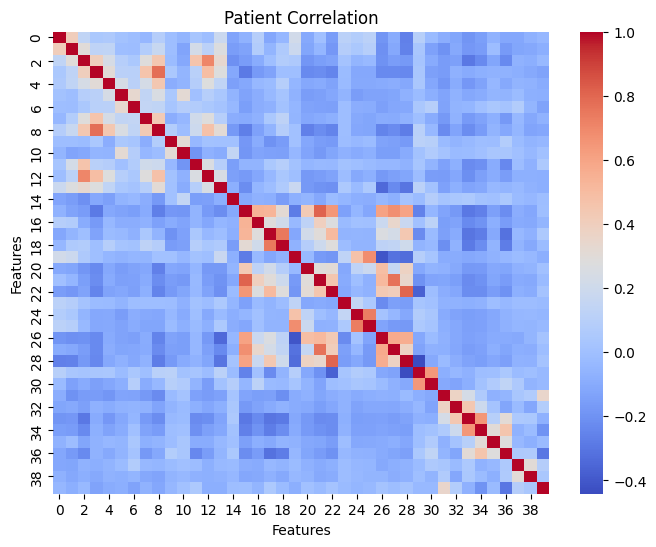

In [129]:
plt.figure(figsize=(8, 6))
sns.heatmap(patient_corr_mat[0], cmap='coolwarm')  #[44:84,44:84]-patient_corr_mat[1].to_numpy()
plt.title('Patient Correlation')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

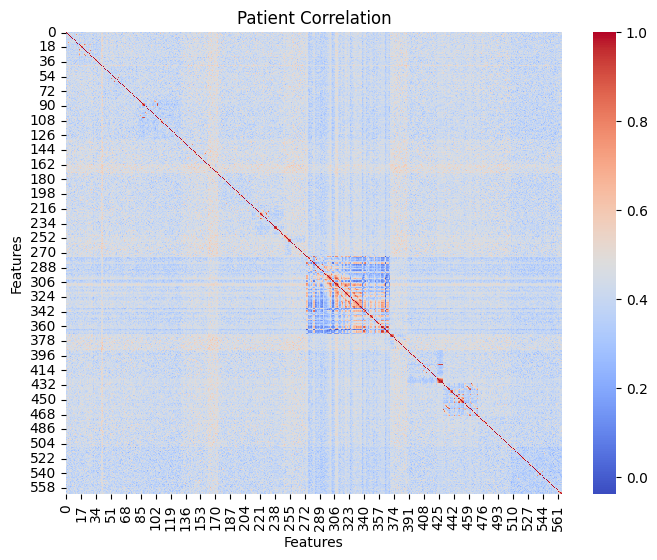

In [143]:
plt.figure(figsize=(8, 6))
sns.heatmap(K, cmap='coolwarm')  #[44:84,44:84]-patient_corr_mat[1].to_numpy()
plt.title('Patient Correlation')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

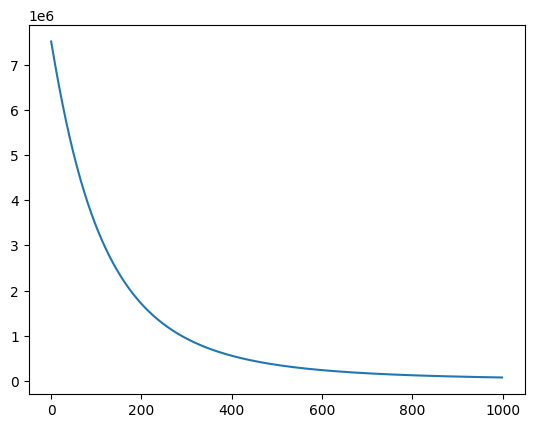

In [119]:
plt.plot(loss)

In [ ]:
pred,indices = single_patient_prediction_pure(0,cleaned_f,(U_det@U_det.T))
held = cleaned_f[1][:,0]
print(cleaned_f[1].shape)
print(held.shape)
row_means = np.mean(held, axis=0, keepdims=True)
row_stds = np.std(held, axis=0, keepdims=True)
held_z_score = (held - row_means) / row_stds

In [ ]:
plt.figure(figsize=(16, 7))
plt.plot(pred[100000:100500,0],label='pred')
plt.plot(held_z_score[100000:100500],label='true_z_score')
plt.legend()

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(U_det@U_det.T, cmap='coolwarm')  #[44:84,44:84]-patient_corr_mat[1].to_numpy()
plt.title('Patient Correlation')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()